# 최종모델
- Catboost + Classweight + optuna 조합

## 모듈 불러오기

In [ ]:
# 모듈 불러오기
import pandas as pd
import numpy as np
import platform
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, balanced_accuracy_score, recall_score,precision_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
import optuna
import joblib

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
# 데이터 불러오기
pre = pd.read_csv('./data/lending_club_preprocessed3.csv')

In [4]:
# 모델용 데이터프레임 생성
modeling = pre.copy()

## 최종피처 선정

In [5]:
# 생성후 Drop / "annual_inc", "revol_bal","installment" 은 개인 판단으로 고고 저는 뺄예정 
modeling = modeling.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])

In [6]:
# 1- 모델을 위해 최적화된 변수 선택 
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1
    # ── 파생 변수 ──
    'installment_to_income', 'loan_to_income', 'revol_bal_to_income'
]

modeling = modeling[use_col]


In [7]:
# test, train 데이터 생성

# 타겟과 피처 분리
y = modeling['target'].astype(int)
X = modeling.drop(columns=['target']).copy()

# 범주형 컬럼
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
num_cols = X.select_dtypes(include=['number']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 파생변수 결측값 채우기
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    train_median = X_train[col].median()                    # train으로만 계산
    X_train[col] = X_train[col].fillna(train_median)       # train에 적용
    X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

# ★train/test 이후 전처리
# dti "sub_grade" 사용해야함 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = X_train.groupby("sub_grade")["dti"].median()
X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc',
'mths_since_rcnt_il',
'mo_sin_old_il_acct'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)
    
# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

### 하이퍼파라미터 튜닝 과정

In [ ]:
# ※주의 : 약 3시간 소요

# 1. train / valid 분리

# Optuna 내부 평가용 validation set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

cat_idx_tr = [X_tr.columns.get_loc(col) for col in cat_cols]

# 2. Optuna objective 함수

def objective(trial):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",   # CatBoost 내부 평가도 PR-AUC 기준
        "random_seed": 42,
        "verbose": 0,
        "auto_class_weights": "Balanced",

        # 튜닝 대상
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_tr, y_tr,
        cat_features=cat_idx_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100
    )

    y_val_proba = model.predict_proba(X_val)[:, 1]

    # sklearn PR-AUC
    pr_auc = average_precision_score(y_val, y_val_proba)

    return pr_auc


# 3. Optuna 실행

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n=== Best Trial ===")
print("Best PR-AUC:", study.best_value)
print("Best Params:")
print(study.best_params)


# 4. 최적 파라미터로 전체 train 학습

best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced"
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 5. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test Performance ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

In [8]:
# 6. 최적 파라미터로 전체 train 학습

# best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    # **best_param,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced",
    max_depth=8,
    iterations=529,
    learning_rate=0.09776608351062278,
    l2_leaf_reg=9.930529846934661,
    min_data_in_leaf=20,
    subsample=0.9703006447340463
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 7. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test Performance ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

0:	learn: 0.6876312	test: 0.6894476	best: 0.6894476 (0)	total: 1.49s	remaining: 13m 5s
100:	learn: 0.7200356	test: 0.7174961	best: 0.7174961 (100)	total: 1m 50s	remaining: 7m 48s
200:	learn: 0.7283627	test: 0.7209491	best: 0.7209491 (200)	total: 3m 30s	remaining: 5m 43s
300:	learn: 0.7345641	test: 0.7222831	best: 0.7222831 (300)	total: 5m 10s	remaining: 3m 54s
400:	learn: 0.7392990	test: 0.7229447	best: 0.7229451 (399)	total: 6m 59s	remaining: 2m 13s
500:	learn: 0.7434300	test: 0.7233109	best: 0.7233191 (499)	total: 8m 41s	remaining: 29.2s
528:	learn: 0.7445473	test: 0.7233992	best: 0.7234025 (526)	total: 9m 10s	remaining: 0us

bestTest = 0.7234024784
bestIteration = 526

Shrink model to first 527 iterations.

=== Test Performance ===
PR-AUC   : 0.4194
ROC-AUC  : 0.7372
Recall   : 0.6790
Precision: 0.3383
F1-score : 0.4516

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8908    0.6635    0.7606    203905
           1     0.3383  

### 임계값 조정

In [9]:

# 1 클래스일 확률
y_proba = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.001)

results = []
best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)

    precision = precision_score(y_test, y_pred_th, zero_division=0)
    recall = recall_score(y_test, y_pred_th, zero_division=0)
    f1 = f1_score(y_test, y_pred_th, zero_division=0)

    results.append({
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

result_df = pd.DataFrame(results)

print("최적 threshold:", best_threshold)
print("최적 F1:", best_f1)

display(result_df.sort_values("f1", ascending=False).head(10))

최적 threshold: 0.5250000000000005
최적 F1: 0.45383528113903543


,threshold,precision,recall,f1
475,0.525,0.352442,0.637131,0.453835
473,0.523,0.351342,0.640674,0.453815
485,0.535,0.358262,0.618856,0.453809
474,0.524,0.351824,0.638970,0.453787
476,0.526,0.353025,0.635021,0.453781
484,0.534,0.357618,0.620637,0.453769
482,0.532,0.356418,0.624199,0.453747
486,0.536,0.358773,0.617017,0.453723
481,0.531,0.355849,0.625806,0.453708
483,0.533,0.356960,0.622321,0.453687


In [10]:
# 적용 후 성능 확인

best_threshold = 0.525
y_pred_opt = (y_proba >= best_threshold).astype(int)


print("=== 최적 threshold 적용 후 성능 ===")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_proba):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_opt):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_opt, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

=== 최적 threshold 적용 후 성능 ===
Threshold : 0.53
Accuracy  : 0.6900
ROC-AUC   : 0.7372
PR-AUC    : 0.4194
Precision : 0.3524
Recall    : 0.6371
F1-score  : 0.4538

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8844    0.7034    0.7836    203905
           1     0.3524    0.6371    0.4538     51655

    accuracy                         0.6900    255560
   macro avg     0.6184    0.6703    0.6187    255560
weighted avg     0.7769    0.6900    0.7170    255560


=== Confusion Matrix ===
[[143436  60469]
 [ 18744  32911]]


<Figure size 1200x700 with 0 Axes>

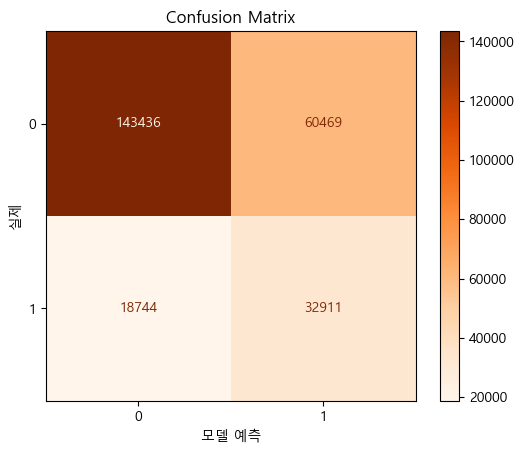

In [11]:
# 혼동행렬 출력
plt.figure(figsize=(12,7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, cmap='Oranges', values_format="d")
plt.title("Confusion Matrix")
plt.xlabel('모델 예측')
plt.ylabel('실제')
plt.show()

### shap 시각화

In [15]:
# shap
import shap

# shap explainer 생성
explainer = shap.TreeExplainer(final_model)

# test 데이터에 대한 shap value 계산
shap_values = explainer.shap_values(X_test)

# 이진분류일 때
# 어떤 환경에서는 list가 아니라 바로 array로 나올 수도 있음
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

print(np.array(shap_values_class1).shape)




(255560, 39)


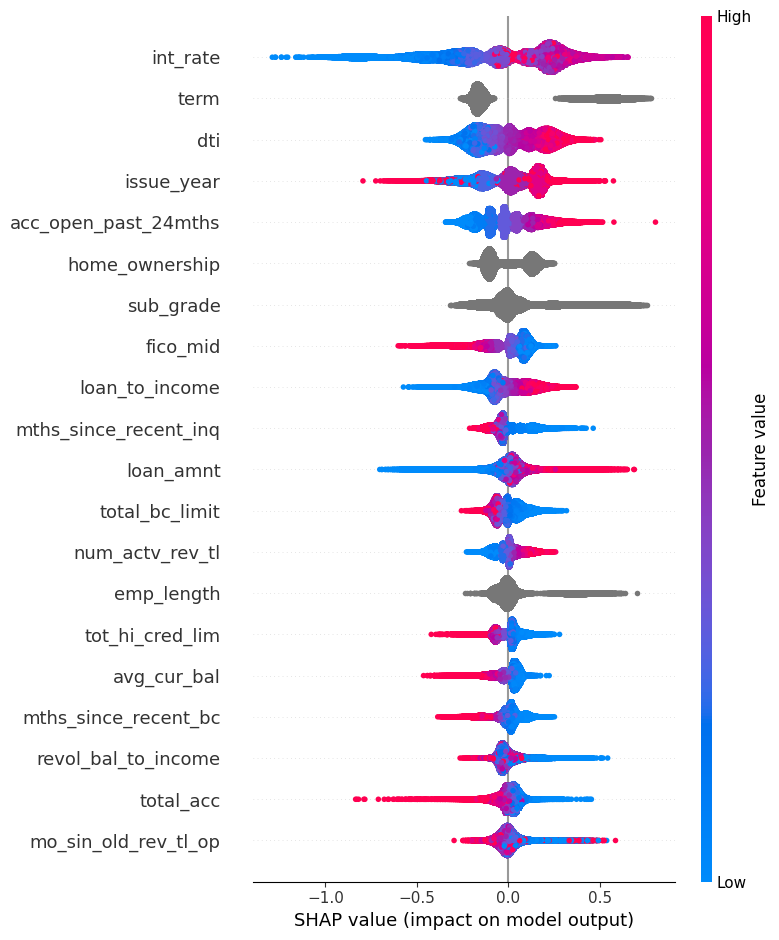

In [ ]:
# shap summary plot 출력
# 모델 예측에 어떤 변수들이 얼마나 영향을 주는지 보여줌
shap.summary_plot(shap_values_class1, X_test)

In [ ]:
# shap으로 구한 Feature importance(변수 중요도) 테이블로 정리
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0) # shap 값의 절댓값 평균(컬럼 기준)
}).sort_values('mean_abs_shap', ascending=False)

display(shap_importance.head(20))

,feature,mean_abs_shap
2,int_rate,0.257180
1,term,0.252515
8,dti,0.146560
5,issue_year,0.133135
22,acc_open_past_24mths,0.130079
7,home_ownership,0.108708
3,sub_grade,0.105840
9,fico_mid,0.094934
37,loan_to_income,0.094115
27,mths_since_recent_inq,0.069853


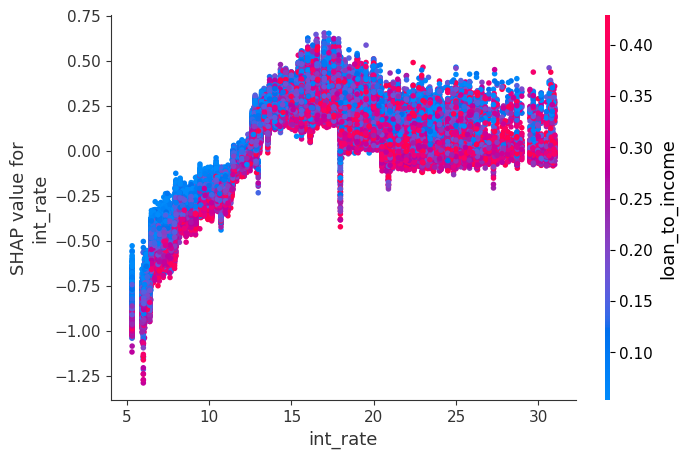

In [ ]:
# shap dependence plot 그리기
# feature importance 1위 int_rate가 모델 예측에 어떻게 영향을 주는지 뽑아주는 코드
shap.dependence_plot('int_rate', shap_values_class1, X_test)

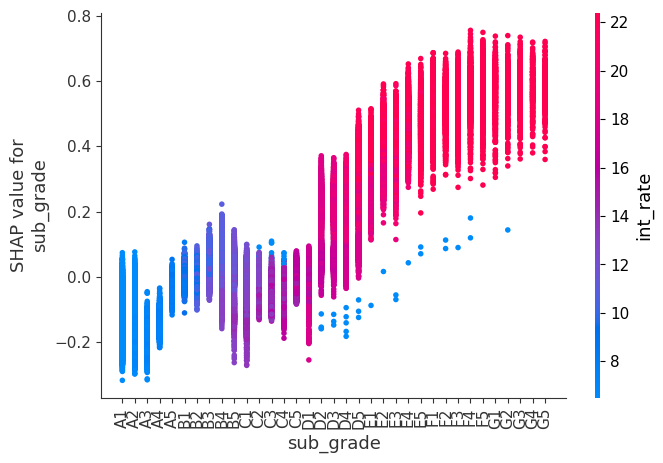

In [ ]:
# shap으로 본 sub_grade가 모델에 주는 영향
shap.dependence_plot('sub_grade', shap_values_class1, X_test)

### 모델 저장

In [ ]:
# 모델 joblib 파일로 저장

model_artifacts = {
    "model": final_model,
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

joblib.dump(model_artifacts, "loan_default_model.joblib")

['loan_default_model.joblib']